In [1]:
%load_ext notellm_magic



  Claude can execute shell commands, read/write/edit files, and access the web.
  Only use in trusted environments.

  Consider removing .claude/settings.local.json when done.


🚀 Claude Code Magic loaded!
Features:
  • Full agentic Claude Code execution
  • Cell-based code approval workflow
  • Real-time message streaming
  • Session state preservation
  • Conversation continuity across cells

Usage:
  %cc <instructions>       # Continue with additional instructions (one-line)
  %%cc <instructions>      # Continue with additional instructions (multi-line)
  %cc_new (or %ccn)        # Start fresh conversation
  %cc --help               # Show available options and usage information

Context management:
  %cc --import <file>       # Add a file to be included in initial conversation messages
  %cc --add-dir <dir>       # Add a directory to Claude's accessible directories
  %cc --mcp-config <file>   # Set path to a .mcp.json file containing MCP server configurations
  %cc --cells-to-loa

In [2]:
%cc hello world

🧠 Claude model: claude-sonnet-4-6
💭 Claude: Hello! How can I help you today?
📍 Claude Code Session ID: d11ba242-a2e7-46fc-a351-54b99517f912


In [3]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter
import matplotlib.pyplot as plt

import operator
from functools import reduce
from functools import partial
from timeit import default_timer

import sys, os
sys.path.append(os.path.abspath(".."))  # or the project root path
from HJR_FNO.neural_utils import *

torch.manual_seed(0)
np.random.seed(0)

#### import functions from OptimizedDP

In [4]:
import imp
import numpy as np

# Utility functions to initialize the problem
from HJR_FNO.HJR_FNO import Grid

# Specify the  file that includes dynamic systems
# from odp.dynamics import DubinsCapture, Plane2D, Plane1D, DubinsCar4D
# Plot options
# from odp.Plots import PlotOptions
# from odp.Plots import visualize_plots, plot_isosurface, plot_valuefunction
# # Solver core
# from odp.solver import HJSolver, computeSpatDerivArray

import math
import os

/tmp/ipykernel_34257/2926833911.py:1: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [5]:

################################################################
#  3D Fourier layer
################################################################
class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, modes3):
        super(SpectralConv3d, self).__init__()
        """
        3D Fourier layer. It does FFT, linear transform, and Inverse FFT.

        modes1: number of Fourier modes to keep along x-dimension
        modes2: number of Fourier modes to keep along y-dimension
        modes3: number of Fourier modes to keep along z/t-dimension
                (at most floor(N/2) + 1 for the last spatial dim)
        """
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3

        self.scale = 1 / (in_channels * out_channels)

        # Four weight tensors to cover the four low-frequency corners in 3D.
        # rfftn halves only the LAST axis (z/t), so kz >= 0 always.
        # The four corners span (±kx, ±ky, +kz):
        #   weights1 → (+kx, +ky, +kz)
        #   weights2 → (-kx, +ky, +kz)
        #   weights3 → (+kx, -ky, +kz)
        #   weights4 → (-kx, -ky, +kz)
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, modes1, modes2, modes3,
                                    dtype=torch.cfloat))
        self.weights2 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, modes1, modes2, modes3,
                                    dtype=torch.cfloat))
        self.weights3 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, modes1, modes2, modes3,
                                    dtype=torch.cfloat))
        self.weights4 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, modes1, modes2, modes3,
                                    dtype=torch.cfloat))

    def compl_mul3d(self, input, weights):
        # (batch, in_ch, x, y, z), (in_ch, out_ch, x, y, z) -> (batch, out_ch, x, y, z)
        return torch.einsum("bixyz,ioxyz->boxyz", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # x shape: (batch, in_ch, X, Y, Z)

        # 1. 3D real FFT → (batch, in_ch, X, Y, Z//2+1)
        x_ft = torch.fft.rfftn(x, dim=[-3, -2, -1])

        # 2. Allocate output frequency tensor (same half-spectrum shape)
        out_ft = torch.zeros(batchsize, self.out_channels,
                             x.size(-3), x.size(-2), x.size(-1) // 2 + 1,
                             device=x.device, dtype=torch.cfloat)

        # 3. Multiply the four low-frequency corners by learned weights.
        #    (+kx, +ky, +kz)
        out_ft[:, :, :self.modes1, :self.modes2, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, :self.modes1, :self.modes2, :self.modes3],
                             self.weights1)
        #    (-kx, +ky, +kz)
        out_ft[:, :, -self.modes1:, :self.modes2, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, -self.modes1:, :self.modes2, :self.modes3],
                             self.weights2)
        #    (+kx, -ky, +kz)
        out_ft[:, :, :self.modes1, -self.modes2:, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, :self.modes1, -self.modes2:, :self.modes3],
                             self.weights3)
        #    (-kx, -ky, +kz)
        out_ft[:, :, -self.modes1:, -self.modes2:, :self.modes3] = \
            self.compl_mul3d(x_ft[:, :, -self.modes1:, -self.modes2:, :self.modes3],
                             self.weights4)

        # 4. Inverse 3D real FFT back to physical space.
        x = torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
        return x


################################################################
#  FNO3d — 4-layer Fourier Neural Operator for 3D problems
################################################################
class FNO3d(nn.Module):
    def __init__(self, modes1, modes2, modes3, width, in_channels=3):
        super(FNO3d, self).__init__()
        """
        3D Fourier Neural Operator with 4 Fourier blocks.

        input:  solution + coordinates (e.g. a(x,y,t), x, y, t)
        input shape:  (batch, X, Y, T, in_channels)
        output shape: (batch, X, Y, T, 1)

        in_channels: number of input features (default 3; adjust to match your data,
                     e.g. 4 if you concatenate [a(x,y,t), x, y, t])
        """
        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3
        self.width  = width

        # ------- Lifting -------
        self.lifting = nn.Conv3d(in_channels, self.width, 1)

        # ------- Fourier blocks -------
        # Spectral (K) paths
        self.conv0 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv1 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv2 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv3 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)

        # Bypass (W) paths — pointwise Conv3d
        self.w0 = nn.Conv3d(self.width, self.width, 1)
        self.w1 = nn.Conv3d(self.width, self.width, 1)
        self.w2 = nn.Conv3d(self.width, self.width, 1)
        self.w3 = nn.Conv3d(self.width, self.width, 1)

        # ------- Projection -------
        self.projection = nn.Conv3d(self.width, 1, 1)

    def forward(self, x):
        # x: (batch, X, Y, T, in_channels)

        # --- Lifting ---
        x = x.permute(0, 4, 1, 2, 3)        # → (batch, in_channels, X, Y, T)
        x = self.lifting(x)                  # → (batch, width, X, Y, T)

        # --- Fourier Block 0 ---
        x1 = self.conv0(x)
        x2 = self.w0(x)
        x  = F.relu(x1 + x2)

        # --- Fourier Block 1 ---
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x  = F.relu(x1 + x2)

        # --- Fourier Block 2 ---
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x  = F.relu(x1 + x2)

        # --- Fourier Block 3 ---
        x1 = self.conv3(x)
        x2 = self.w3(x)
        x  = F.relu(x1 + x2)

        # --- Projection ---
        x = self.projection(x)               # → (batch, 1, X, Y, T)
        x = x.permute(0, 2, 3, 4, 1)        # → (batch, X, Y, T, 1)
        return x


# Quick sanity check
modes, width = 12, 32
model = FNO3d(modes1=modes, modes2=modes, modes3=modes, width=width, in_channels=3).to(device)
# x_test = torch.randn(2, 50, 50, 20, 3).to(device)   # (batch, X, Y, T, in_channels)
# y_test = model(x_test)
# print(f"Input:  {tuple(x_test.shape)}")
# print(f"Output: {tuple(y_test.shape)}")
# print(f"Params: {count_params(model):,}")


In [6]:
import numpy as np
import scipy.io as sio

################################################################
# Load .mat file(s)
################################################################
def load_mat(path: str) -> dict:
    """
    Load a .mat file saved by data_gen/dubins3D_data_gen.py (DubinsCar2, 3D state).
    Returns a plain dict with numpy arrays:
      constraints : (M, nx, ny, nth)        — obstacle SDF per sample (3D: x,y,theta)
      results     : (M, nx, ny, nth, T)     — reach-avoid BRT time history per sample
      target_set  : (nx, ny, nth)           — fixed target SDF
      tau         : (T,)                     — time vector
      x_axis      : (nx,)
      y_axis      : (ny,)
      theta_axis  : (nth,)                   — heading axis (periodic)
    """
    raw = sio.loadmat(path, squeeze_me=True)
    return {
        "constraints": raw["constraints"].astype(np.float32),  # (M, nx, ny, nth)
        "results":     raw["results"].astype(np.float32),      # (M, nx, ny, nth, T)
        "target_set":  raw["target_set"].astype(np.float32),   # (nx, ny, nth)
        "tau":         raw["tau"].astype(np.float32),          # (T,)
        "x_axis":      raw["x_axis"].astype(np.float32),       # (nx,)
        "y_axis":      raw["y_axis"].astype(np.float32),       # (ny,)
        "theta_axis":  raw["theta_axis"].astype(np.float32),   # (nth,)
    }

def extract_input(data: dict) -> np.ndarray:
    """
    Input to the network: obstacle SDF, shape (M, nx, ny, nth).

    Sign convention (unchanged): we negate so the SAFE interior is negative.
    Note dubins3D_data_gen stores the RAW odp SDF (negative INSIDE the obstacle),
    so -constraints is positive inside the obstacle / negative in free space.
    """
    return -data["constraints"]   # (M, nx, ny, nth)

def extract_output(data: dict, t_idx: int = -1) -> np.ndarray:
    """
    Output of the network: BRT value function at a given time index.
      t_idx = -1 -> final time step (fully grown BRT)   [default]
      t_idx =  k -> slice at tau[k]
    Time is the LAST axis now (axis 4), so index with [..., t_idx].

    Returns shape (M, nx, ny, nth).
    """
    return data["results"][..., t_idx]   # (M, nx, ny, nth)

################################################################
# Read data
################################################################
data1 = load_mat("/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/data_gen/HJB_training_mat/DubinsCar2_50x50x36_reach_avoid.mat")

x_data = np.concatenate([
    extract_input(data1),
], axis=0)   # (M_total, nx, ny, nth)

y_data = np.concatenate([
    data1["results"],   # (M, nx, ny, nth, T)
], axis=0)

print("input  shape:", x_data.shape)   # (M, 50, 50, 36)
print("output shape:", y_data.shape)   # (M, 50, 50, 36, T)

print("========================")
print("x-axis    ", data1["x_axis"])
print("y-axis    ", data1["y_axis"])
print("theta-axis", data1["theta_axis"])
print("time array", data1["tau"])


input  shape: (100, 50, 50, 36)
output shape: (100, 50, 50, 36, 17)
x-axis     [-10.          -9.591837    -9.183674    -8.77551     -8.367347
  -7.9591837   -7.5510206   -7.142857    -6.734694    -6.3265305
  -5.9183674   -5.5102043   -5.102041    -4.6938777   -4.285714
  -3.877551    -3.4693878   -3.0612245   -2.6530612   -2.2448978
  -1.8367347   -1.4285715   -1.0204082   -0.6122449   -0.20408164
   0.20408164   0.6122449    1.0204082    1.4285715    1.8367347
   2.2448978    2.6530612    3.0612245    3.4693878    3.877551
   4.285714     4.6938777    5.102041     5.5102043    5.9183674
   6.3265305    6.734694     7.142857     7.5510206    7.9591837
   8.367347     8.77551      9.183674     9.591837    10.        ]
y-axis     [-10.          -9.591837    -9.183674    -8.77551     -8.367347
  -7.9591837   -7.5510206   -7.142857    -6.734694    -6.3265305
  -5.9183674   -5.5102043   -5.102041    -4.6938777   -4.285714
  -3.877551    -3.4693878   -3.0612245   -2.6530612   -2.2448978
  

### Define grid object

In [7]:
import sys
import os

sys.path.insert(0, '/home/kmuenpra/git/tTLT/optimized_dp')

import numpy as np
from odp.Grid import Grid
from odp.Shapes   import CylinderShape, ShapeRectangle, ShapeEllipsoid


g = Grid(
    minBounds    = np.array([-10.0, -10.0, -math.pi]),
    maxBounds    = np.array([ 10.0,  10.0,  math.pi]),
    dims         = 3,
    pts_each_dim = np.array([50, 50, 36]),
    periodicDims = [2],
)

print(f"x: [{g.grid_points[0][0]:.2f}, {g.grid_points[0][-1]:.2f}]")
print(f"y: [{g.grid_points[1][0]:.2f}, {g.grid_points[1][-1]:.2f}]")

x: [-10.00, 10.00]
y: [-10.00, 10.00]


### Visualize dataset

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

################################################################
# Data (loaded earlier via load_mat / extract_*)
#   x_data : (M, nx, ny, nth)      — negated obstacle SDFs (+ inside obstacle)
#   y_data : (M, nx, ny, nth, T)   — reach-avoid BRT time history
#   data1  : dict from load_mat()
################################################################
x_axis     = data1["x_axis"]       # (nx,)
y_axis     = data1["y_axis"]       # (ny,)
theta_axis = data1["theta_axis"]   # (nth,)
tau        = data1["tau"]          # (T,)
nth, T     = len(theta_axis), len(tau)

# ── Pick a sample and a RANDOM fixed heading slice ────────────────────────────
sample_idx = 67                            # which obstacle configuration in [0, M)
th_idx     = int(np.random.randint(nth))   # fixed theta, chosen at random
theta_val  = float(theta_axis[th_idx])
print(f"sample={sample_idx}  theta_idx={th_idx}/{nth-1}  theta={theta_val:+.3f} rad")

X, Y = np.meshgrid(x_axis, y_axis, indexing="ij")

# Slices at the chosen heading. Sign conventions:
#   obstacle (raw odp SDF)  : < 0  inside obstacle
#   target  (CylinderShape) : < 0  inside target
#   BRT value V             : <= 0 inside backward-reachable set
obstacle = data1["constraints"][sample_idx, :, :, th_idx]   # (nx, ny)
target   = data1["target_set"][:, :, th_idx]                # (nx, ny)
brt_all  = y_data[sample_idx, :, :, th_idx, :]              # (nx, ny, T)

# Fixed colour scale across all frames.
vmin = float(np.percentile(brt_all, 2))
vmax = float(np.percentile(brt_all, 98))

legend_handles = [
    plt.Line2D([0], [0], color="blue",  lw=2,            label="BRT boundary (V=0)"),
    plt.Line2D([0], [0], color="red",   lw=2, ls="--",   label="Obstacle"),
    plt.Line2D([0], [0], color="green", lw=2, ls="--",   label="Target"),
]

fig, ax = plt.subplots(figsize=(6.5, 5.5))

def draw(frame: int):
    # Animate lookback time from tau[-1] (=8 s) down to tau[0] (=0 s).
    k = T - 1 - frame
    V = brt_all[:, :, k]
    ax.clear()

    # BRT value background + zero-level boundary
    ax.contourf(X, Y, V, levels=40, cmap="Blues_r", vmin=vmin, vmax=vmax, alpha=0.9)
    ax.contour(X, Y, V, levels=[0.0], colors="blue", linewidths=2)

    # Obstacle: filled + dashed boundary (red)
    ax.contourf(X, Y, obstacle, levels=[obstacle.min(), 0.0], colors=["red"], alpha=0.30)
    ax.contour(X, Y, obstacle, levels=[0.0], colors="red", linewidths=2, linestyles="--")

    # Target: dashed boundary (green)
    ax.contour(X, Y, target, levels=[0.0], colors="green", linewidths=2, linestyles="--")

    ax.set_title(f"Backward Reachable Set | θ={theta_val:+.2f} rad | t = {tau[k]:.1f} s")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(x_axis[0], x_axis[-1]); ax.set_ylim(y_axis[0], y_axis[-1])
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.legend(handles=legend_handles, loc="upper right", fontsize=8)

anim = FuncAnimation(fig, draw, frames=T, interval=400, repeat=True)
plt.close(fig)             # avoid a duplicate static frame in the notebook
HTML(anim.to_jshtml())     # render the animation inline


sample=67  theta_idx=0/35  theta=-3.142 rad


In [9]:
################################################################
#  Split Train and Test data
################################################################

N = x_data.shape[0] 
perm = np.random.permutation(N)

train_ratio = 0.90   # 95% train
N_train = int(train_ratio * N)

train_idx = perm[:N_train]
test_idx  = perm[N_train:]

x_train = x_data[train_idx,...]
y_train = y_data[train_idx,...]

x_test  = x_data[test_idx,...]
y_test  = y_data[test_idx,...]

print("data input", x_train.shape)
print("data output", y_train.shape)


data input (90, 50, 50, 36)
data output (90, 50, 50, 36, 17)


In [10]:
################################################################
#  Append Training & Testing data with 5 Spatial Channels (3D)  — RAW (no normalization)
#  Channels: (SDF, x, y, t, theta) — broadcast to 3D grid (Nx, Ny, T)
#  THETA is a CONSTANT 5th channel; each (sample, theta-slice) pair = one example.
#
#  x_data: (N, Nx, Ny, nth)      — negated obstacle SDF
#  y_data: (N, Nx, Ny, nth, T)   — reach-avoid BRT over T time slices
#  Output (M = N_samples * n_theta):
#    xx : (M, Nx, Ny, T, 5)  — [SDF, x, y, t, theta]
#    yy : (M, Nx, Ny, T, 1)  — V(x, y, t)
################################################################

import torch
import numpy as np

# ---- Hyperparameters --------------------------------------------------------
time_hyparam = data1["tau"]          # (T,) time values
stride       = 1
time_i       = range(len(time_hyparam))[::stride]

# Heading (theta) slices — treated as a constant channel, not a grid axis.
theta_axis   = data1["theta_axis"]   # (nth,) from -pi to pi
theta_stride = 2                     # 1 -> use ALL headings; increase to subsample
theta_i      = range(len(theta_axis))[::theta_stride]

# Spatial grid
xs = data1["x_axis"]                 # (Nx,)
ys = data1["y_axis"]                 # (Ny,)
X_grid, Y_grid = np.meshgrid(xs, ys, indexing='ij')   # (Nx, Ny) each
X_torch = torch.tensor(X_grid, dtype=torch.float32)   # (Nx, Ny)
Y_torch = torch.tensor(Y_grid, dtype=torch.float32)   # (Nx, Ny)


# ---- Helper -----------------------------------------------------------------
def build_dataset(sdf_data, reach_data, indices, time_indices, theta_indices,
                  X_torch, Y_torch, theta_axis):
    """
    Build a 3D-grid dataset (FNO3d over x, y, t) with THETA as a constant
    5th channel. Each (sample, theta) pair is flattened into the batch dim.

        xx : torch.Tensor (M, Nx, Ny, T, 5)  — [SDF, x, y, t, theta]
        yy : torch.Tensor (M, Nx, Ny, T, 1)  — V(x, y, t) at fixed theta
        where M = N_samples * n_theta
    """
    Nx, Ny    = sdf_data.shape[1], sdf_data.shape[2]
    time_list = list(time_indices)
    th_list   = list(theta_indices)
    T         = len(time_list)
    N         = sdf_data.shape[0]
    n_theta   = len(th_list)
    M         = N * n_theta

    xx = torch.empty(M, Nx, Ny, T, 5, dtype=torch.float32)
    yy = torch.empty(M, Nx, Ny, T, 1, dtype=torch.float32)

    x_3d = X_torch.unsqueeze(-1).expand(Nx, Ny, T)             # (Nx, Ny, T)
    y_3d = Y_torch.unsqueeze(-1).expand(Nx, Ny, T)             # (Nx, Ny, T)
    time_vals = torch.tensor(
        [float(time_hyparam[t_i]) for t_i in time_list], dtype=torch.float32)
    t_3d = time_vals.view(1, 1, T).expand(Nx, Ny, T)           # (Nx, Ny, T)

    m = 0
    for j in range(N):
        for th in th_list:
            theta_val = float(theta_axis[th])

            sdf_slice = torch.tensor(sdf_data[j, :, :, th], dtype=torch.float32)  # (Nx, Ny)
            xx[m, :, :, :, 0] = sdf_slice.unsqueeze(-1).expand(Nx, Ny, T)
            xx[m, :, :, :, 1] = x_3d
            xx[m, :, :, :, 2] = y_3d
            xx[m, :, :, :, 3] = t_3d
            xx[m, :, :, :, 4] = theta_val

            reach_3d = torch.tensor(
                reach_data[j, :, :, th, :][:, :, time_list], dtype=torch.float32)  # (Nx, Ny, T)
            yy[m, :, :, :, 0] = reach_3d
            m += 1

    return xx, yy


# ---- Build datasets ---------------------------------------------------------
xx_train, yy_train = build_dataset(
    x_train, y_train, train_idx, time_i, theta_i, X_torch, Y_torch, theta_axis)
xx_test, yy_test = build_dataset(
    x_test, y_test, test_idx, time_i, theta_i, X_torch, Y_torch, theta_axis)

n_theta = len(list(theta_i))
print(f"n_theta = {n_theta}  (theta_stride={theta_stride}),  T = {len(list(time_i))}  (stride={stride})")
for ch, nm in enumerate(["sdf", "x", "y", "t", "theta"]):
    print(f"  ch{ch} {nm:5s}: [{xx_train[..., ch].min():+.3f}, {xx_train[..., ch].max():+.3f}]")
print(f"  V range: [{yy_train.min():+.3f}, {yy_train.max():+.3f}]")
print("Train input  shape:", xx_train.shape)
print("Train output shape:", yy_train.shape)
print("Test  input  shape:", xx_test.shape)
print("Test  output shape:", yy_test.shape)


n_theta = 18  (theta_stride=2),  T = 17  (stride=1)
  ch0 sdf  : [-25.803, +1.923]
  ch1 x    : [-10.000, +10.000]
  ch2 y    : [-10.000, +10.000]
  ch3 t    : [+0.000, +8.000]
  ch4 theta: [-3.142, +2.793]
  V range: [-1.928, +12.142]
Train input  shape: torch.Size([1620, 50, 50, 17, 5])
Train output shape: torch.Size([1620, 50, 50, 17, 1])
Test  input  shape: torch.Size([180, 50, 50, 17, 5])
Test  output shape: torch.Size([180, 50, 50, 17, 1])


### Load/Train Model

In [14]:
################################################################
# Training (DubinsCar2, 5-channel, RAW data) — data-driven
#
#   Loss = relative-L2 + boundary-weighted MSE (focus on {V=0}) + terminal
#          anchor (V at the target slice = max(l, -g)).  All in RAW units.
#
#   No HJI residual: the Plane2D Hamiltonian is wrong for DubinsCar2, and the
#   Dubins HJ-VI needs dV/dtheta, unavailable when theta is a fixed channel.
################################################################
import os
from timeit import default_timer
from torch.utils.data import DataLoader, TensorDataset

# ── Loss weights (raw-unit data; tune with the ep0 magnitude print) ──────────
LAMBDA_BND   = 1.0      # near-boundary data fidelity
LAMBDA_TERM  = 1e-4     # terminal/target-slice anchor
SIGMA_BND    = 1.0      # boundary kernel width, in RAW V units (tune)

SAVE_PATH = '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/training/model/01_FNO3d_dubins_5ch_tuned.pt'
CKPT_PATH = '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/training/model/01_FNO3d_dubins_5ch_tuned_checkpoint.pt'
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)

# Fixed target SDF l (theta-independent: ignore_dims=[2]) — RAW units, 2D slice.
_l_tensor = torch.tensor(data1["target_set"][:, :, 0], dtype=torch.float32).to(device)  # (Nx,Ny)

# ── Sanity checks ────────────────────────────────────────────────────────────
print("=== Input sanity check (raw) ===")
print(f"xx_train shape:        {tuple(xx_train.shape)}")
for ch, nm in enumerate(["sdf", "x", "y", "t", "theta"]):
    print(f"  ch{ch} {nm:5s}: [{xx_train[..., ch].min():.3f}, {xx_train[..., ch].max():.3f}]")
print(f"yy_train (V*) range:   [{yy_train.min():.3f}, {yy_train.max():.3f}]")
print()

# ── Model: FNO3d, 5 input channels ───────────────────────────────────────────
model_5ch = FNO3d(modes1=12, modes2=12, modes3=6, width=24, in_channels=5).to(device)
print(f"Parameters: {sum(p.numel() for p in model_5ch.parameters()):,}")

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 32
train_loader4 = DataLoader(TensorDataset(xx_train, yy_train),
                           batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader4  = DataLoader(TensorDataset(xx_test,  yy_test),
                           batch_size=BATCH_SIZE, shuffle=False)
print(f"Train batches: {len(train_loader4)}  |  Test batches: {len(test_loader4)}")

# ── Relative L2 loss ─────────────────────────────────────────────────────────
class LpLoss(object):
    """Relative L2: ||y - y*||_2 / ||y*||_2, averaged over batch."""
    def __init__(self, p=2, eps=1e-8):
        self.p, self.eps = p, eps
    def __call__(self, y, y_star):
        B = y.size(0)
        diff = (y - y_star).reshape(B, -1)
        norm = y_star.reshape(B, -1)
        num  = torch.norm(diff, p=self.p, dim=1)
        den  = torch.norm(norm, p=self.p, dim=1) + self.eps
        return (num / den).mean()

rel_l2 = LpLoss(p=2)

# ── Boundary-weighted MSE: upweights points near {V*=0} ──────────────────────
def boundary_weighted_mse(V_pred, V_star, sigma=SIGMA_BND):
    w = torch.exp(-(V_star.detach() ** 2) / (2 * sigma ** 2))   # ~1 near boundary, ~0 far
    return (w * (V_pred - V_star) ** 2).sum() / (w.sum() + 1e-8)

# ── Terminal/target-slice target: V(target slice) = max(l, -g) ───────────────
# odp convention: result[..., -1] is the terminal condition; ch0 = -g (raw).
def terminal_target(x_b):
    ch0_T = x_b[:, :, :, -1, 0]                                    # (B,Nx,Ny) = -g (raw)
    l_b   = _l_tensor.unsqueeze(0).expand(x_b.size(0), -1, -1)     # (B,Nx,Ny) raw target
    return torch.maximum(l_b, ch0_T)

# ── Training schedule (single phase) ─────────────────────────────────────────
TOTAL_EPOCHS    = 120
LR_MAX, LR_MIN  = 1e-3, 1e-5

optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR_MAX, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TOTAL_EPOCHS * len(train_loader4), eta_min=LR_MIN)

global_step = 0
best_val    = float('inf')
printed_magnitudes = False

if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model_5ch.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    global_step = ckpt['global_step']
    print(f"Loaded checkpoint (epoch {start_epoch}); delete {CKPT_PATH} to retrain.")

else:
    for epoch in range(TOTAL_EPOCHS):
        model_5ch.train()
        t0 = default_timer()
        ep_data = ep_bnd = ep_term = 0.0

        for x_b, y_b in train_loader4:
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            optimizer.zero_grad()
            V_pred = model_5ch(x_b)

            loss_data = rel_l2(V_pred, y_b)
            loss_bnd  = boundary_weighted_mse(V_pred, y_b)
            loss_term = F.mse_loss(V_pred[:, :, :, -1, 0], terminal_target(x_b))

            loss = loss_data + LAMBDA_BND * loss_bnd + LAMBDA_TERM * loss_term

            if not printed_magnitudes and epoch == 0:
                with torch.no_grad():
                    print(f"\n[loss magnitudes @ ep0 batch0] "
                          f"data={loss_data.item():.3e}  bnd={loss_bnd.item():.3e}  "
                          f"term={loss_term.item():.3e}\n")
                printed_magnitudes = True

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            ep_data += loss_data.item()
            ep_bnd  += loss_bnd.item()
            ep_term += loss_term.item()
            global_step += 1

        model_5ch.eval()
        test_rel = test_mse = test_linf = 0.0
        with torch.no_grad():
            for x_b, y_b in test_loader4:
                x_b, y_b = x_b.to(device), y_b.to(device)
                out = model_5ch(x_b)
                test_rel  += rel_l2(out, y_b).item()
                test_mse  += F.mse_loss(out, y_b).item()
                test_linf += (out - y_b).abs().max().item()

        nb_te = len(test_loader4)
        test_rel  /= nb_te
        test_mse  /= nb_te
        test_linf /= nb_te

        if test_rel < best_val:
            best_val = test_rel
            torch.save(model_5ch, SAVE_PATH)

        nb = len(train_loader4)
        t1 = default_timer()
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Ep {epoch:03d} | {t1-t0:5.1f}s | lr={lr_now:.2e} | "
              f"data={ep_data/nb:.3e}  bnd={ep_bnd/nb:.3e}  term={ep_term/nb:.3e} | "
              f"val_rel={test_rel:.3e}  val_mse={test_mse:.3e}  val_L∞={test_linf:.3e}")

    torch.save({
        'model_state_dict':     model_5ch.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': TOTAL_EPOCHS - 1,
        'global_step': global_step,
        'lambda_term': LAMBDA_TERM, 'lambda_bnd': LAMBDA_BND, 'sigma_bnd': SIGMA_BND,
        'best_val_rel_l2': best_val,
    }, CKPT_PATH)
    print(f"\nBest model (val rel L2 = {best_val:.3e}) → {SAVE_PATH}")
    print(f"Final checkpoint                          → {CKPT_PATH}")


=== Input sanity check (raw) ===
xx_train shape:        (1620, 50, 50, 17, 5)
  ch0 sdf  : [-25.803, 1.923]
  ch1 x    : [-10.000, 10.000]
  ch2 y    : [-10.000, 10.000]
  ch3 t    : [0.000, 8.000]
  ch4 theta: [-3.142, 2.793]
yy_train (V*) range:   [-1.928, 12.142]

Parameters: 7,965,193
Train batches: 50  |  Test batches: 6

[loss magnitudes @ ep0 batch0] data=1.016e+00  bnd=1.068e+00  term=4.343e+01

Ep 000 |  21.5s | lr=1.00e-03 | data=5.610e-01  bnd=5.519e-01  term=1.946e+01 | val_rel=1.809e-01  val_mse=7.006e-01  val_L∞=3.426e+00
Ep 001 |  21.6s | lr=9.99e-04 | data=1.449e-01  bnd=2.567e-01  term=5.137e-01 | val_rel=1.307e-01  val_mse=3.823e-01  val_L∞=2.806e+00
Ep 002 |  21.7s | lr=9.98e-04 | data=1.104e-01  bnd=1.158e-01  term=9.254e-02 | val_rel=9.264e-02  val_mse=1.904e-01  val_L∞=2.130e+00
Ep 003 |  21.7s | lr=9.97e-04 | data=7.324e-02  bnd=4.461e-02  term=4.499e-02 | val_rel=5.719e-02  val_mse=7.308e-02  val_L∞=1.608e+00
Ep 004 |  21.8s | lr=9.96e-04 | data=4.624e-02  bnd=2

### [Optional] Extra training for pre-trained model using checkpoint


In [ ]:

################################################################
# Resume Training from Checkpoint
#   Picks up model, optimizer, epoch, global_step, and alpha
#   from CKPT_PATH and runs EXTRA_EPOCHS more epochs with the
#   same 4-term loss (data + boundary + residual + terminal).
################################################################
from timeit import default_timer

EXTRA_EPOCHS = 150   # ← change as needed for additional epochs

# ── Load checkpoint ───────────────────────────────────────────
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

model_4ch.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])

start_epoch = ckpt['epoch'] + 1
end_epoch   = start_epoch + EXTRA_EPOCHS
global_step = ckpt['global_step']
alpha       = ckpt.get('alpha', ALPHA_END)   # resume annealing state
best_val    = ckpt.get('best_val_rel_l2', float('inf'))

# Rebuild scheduler so it steps from the already-elapsed position
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=end_epoch * len(train_loader4),
    eta_min=LR_MIN,
    last_epoch=global_step - 1,   # tells scheduler where we are
)

print(f"Resuming from epoch {start_epoch} → {end_epoch - 1}  "
      f"(global_step={global_step}, alpha={alpha:.2f}, best_val={best_val:.3e})")

# ── Training loop ─────────────────────────────────────────────
for epoch in range(start_epoch, end_epoch):
    model_4ch.train()
    t0 = default_timer()
    ep_data = ep_bnd = ep_res = ep_term = 0.0

    for x_b, y_b in train_loader4:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        optimizer.zero_grad()
        V_pred = model_4ch(x_b)

        g_b = -x_b[:, :, :, 0, 0]
        l_b = _l_tensor.unsqueeze(0).expand(x_b.size(0), -1, -1)

        loss_data = rel_l2(V_pred, y_b)
        loss_bnd  = boundary_weighted_mse(V_pred, y_b)
        loss_term = F.mse_loss(V_pred[:, :, :, -1, 0],
                               torch.maximum(l_b, -g_b))
        res       = hji_residual(V_pred, g_b, l_b)
        loss_res  = (res ** 2).mean()

        # Always in the L∞ phase since we're past PRETRAIN_EPOCHS
        alpha     = min(ALPHA_END, alpha + alpha_step)
        loss_linf = smooth_linf(res.reshape(res.size(0), -1).abs(), alpha)
        loss = (loss_data
                + LAMBDA_BND  * loss_bnd
                + LAMBDA_RES  * loss_res
                + LAMBDA_LINF * loss_linf
                + LAMBDA_TERM * loss_term)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_4ch.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        ep_data += loss_data.item()
        ep_bnd  += loss_bnd.item()
        ep_res  += loss_res.item()
        ep_term += loss_term.item()
        global_step += 1

    # ── Eval ─────────────────────────────────────────────────
    model_4ch.eval()
    test_rel = test_mse = test_linf = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader4:
            x_b, y_b = x_b.to(device), y_b.to(device)
            out = model_4ch(x_b)
            test_rel  += rel_l2(out, y_b).item()
            test_mse  += F.mse_loss(out, y_b).item()
            test_linf += (out - y_b).abs().max().item()

    nb_te = len(test_loader4)
    test_rel  /= nb_te
    test_mse  /= nb_te
    test_linf /= nb_te

    if test_rel < best_val:
        best_val = test_rel
        torch.save(model_4ch, SAVE_PATH)

    nb  = len(train_loader4)
    t1  = default_timer()
    lr_now = optimizer.param_groups[0]['lr']
    print(f"[L∞(α={alpha:.1f})] Ep {epoch:03d} | {t1-t0:5.1f}s | lr={lr_now:.2e} | "
          f"data={ep_data/nb:.3e}  bnd={ep_bnd/nb:.3e}  "
          f"res={ep_res/nb:.3e}  term={ep_term/nb:.3e} | "
          f"val_rel={test_rel:.3e}  val_mse={test_mse:.3e}  val_L∞={test_linf:.3e}")

# ── Save updated checkpoint ───────────────────────────────────
torch.save({
    'model_state_dict':     model_4ch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch':       end_epoch - 1,
    'global_step': global_step,
    'alpha':       alpha,
    'lambda_res':  LAMBDA_RES,  'lambda_linf': LAMBDA_LINF,
    'lambda_term': LAMBDA_TERM, 'lambda_bnd':  LAMBDA_BND,
    'best_val_rel_l2': best_val,
}, CKPT_PATH)
print(f"\nBest model (val rel L2 = {best_val:.3e}) → {SAVE_PATH}")
print(f"Checkpoint updated                        → {CKPT_PATH}")


### Predict on the test data

Full BRT pred: (50, 50, 36, 17)  | GT: (50, 50, 36, 17)
Max abs error (whole volume): 0.6958


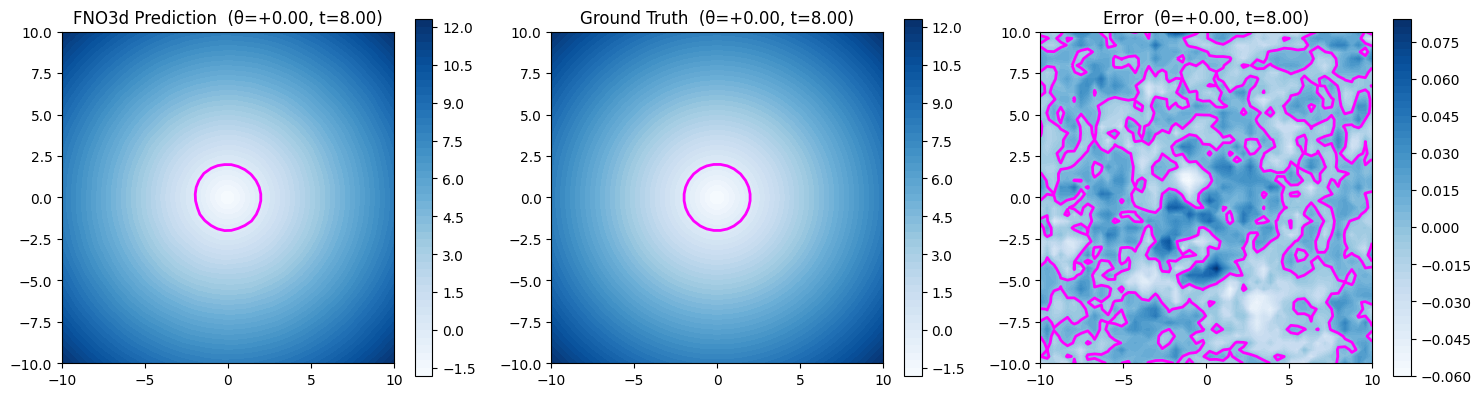

In [ ]:
################################################################
#  Query a trained FNO3d (5-channel: SDF, x, y, t, theta) — RAW, resolution-flexible
#
#  query_FNO3d        : one fixed theta  -> (Nx, Ny, T)
#  query_FNO3d_full   : sweep all theta  -> (Nx, Ny, Nth, T)   (full 3D BRT)
#
#  Resolution-invariant: pass any x_axis / y_axis / tau / theta_axis. The FNO
#  works at any grid size that satisfies its mode minimums:
#     Nx, Ny >= 2*modes1 (= 32 for modes1=16),   T >= 2*modes3 - 1 (= 15 for modes3=8)
################################################################

def _build_input_5ch(constraint_sdf, theta_vals, x_axis, y_axis, tau):
    """Return a torch tensor (B, Nx, Ny, T, 5) for B = len(theta_vals).
       Channels [sdf, x, y, t, theta] in RAW units (matches training)."""
    x_axis = np.asarray(x_axis, np.float32)
    y_axis = np.asarray(y_axis, np.float32)
    tau    = np.asarray(tau,    np.float32)
    theta_vals = np.atleast_1d(np.asarray(theta_vals, np.float32))
    Nx, Ny, T, B = len(x_axis), len(y_axis), len(tau), len(theta_vals)
    assert constraint_sdf.shape == (Nx, Ny), \
        f"constraint_sdf {constraint_sdf.shape} != grid ({Nx},{Ny})"

    sdf_neg = torch.tensor(-np.asarray(constraint_sdf, np.float32))     # ch0 = -g
    Xg, Yg  = np.meshgrid(x_axis, y_axis, indexing="ij")
    sdf_3d = sdf_neg.unsqueeze(-1).expand(Nx, Ny, T)
    x_3d   = torch.tensor(Xg).unsqueeze(-1).expand(Nx, Ny, T)
    y_3d   = torch.tensor(Yg).unsqueeze(-1).expand(Nx, Ny, T)
    t_3d   = torch.tensor(tau).view(1, 1, T).expand(Nx, Ny, T)

    base = torch.stack([sdf_3d, x_3d, y_3d, t_3d,
                        torch.zeros(Nx, Ny, T)], dim=-1)               # (Nx,Ny,T,5)
    x_in = base.unsqueeze(0).repeat(B, 1, 1, 1, 1)                     # (B,Nx,Ny,T,5)
    for b, th in enumerate(theta_vals):
        x_in[b, :, :, :, 4] = float(th)                               # constant theta channel
    return x_in


def query_FNO3d(constraint_sdf, theta_val, model=None,
                x_axis=None, y_axis=None, tau=None,
                return_all_times=True, t_idx=-1, device=device):
    """Single fixed-theta query -> (Nx, Ny, T) (or (Nx,Ny) if return_all_times=False)."""
    if model is None:
        model = torch.load(SAVE_PATH, map_location=device, weights_only=False)
    model.eval()
    if x_axis is None: x_axis = data1["x_axis"]
    if y_axis is None: y_axis = data1["y_axis"]
    if tau    is None: tau    = data1["tau"]

    x_in = _build_input_5ch(constraint_sdf, [theta_val], x_axis, y_axis, tau)
    with torch.no_grad():
        V = model(x_in.to(device))[0, :, :, :, 0].float().cpu().numpy()   # (Nx,Ny,T)
    return V if return_all_times else V[:, :, t_idx]


def query_FNO3d_full(constraint_sdf, model=None,
                     x_axis=None, y_axis=None, theta_axis=None, tau=None,
                     device=device, chunk=12):
    """Full 3D BRT: sweep every theta, stack -> (Nx, Ny, Nth, T).
       theta is batched (chunked) so it's one (or a few) forward passes, not Nth."""
    if model is None:
        model = torch.load(SAVE_PATH, map_location=device, weights_only=False)
    model.eval()
    if x_axis     is None: x_axis     = data1["x_axis"]
    if y_axis     is None: y_axis     = data1["y_axis"]
    if theta_axis is None: theta_axis = data1["theta_axis"]
    if tau        is None: tau        = data1["tau"]
    theta_axis = np.asarray(theta_axis, np.float32)
    Nx, Ny, Nth, T = len(x_axis), len(y_axis), len(theta_axis), len(tau)

    V_full = np.empty((Nx, Ny, Nth, T), dtype=np.float32)
    for s in range(0, Nth, chunk):
        th_chunk = theta_axis[s:s + chunk]
        x_in = _build_input_5ch(constraint_sdf, th_chunk, x_axis, y_axis, tau)  # (B,Nx,Ny,T,5)
        with torch.no_grad():
            out = model(x_in.to(device))[..., 0].float().cpu().numpy()          # (B,Nx,Ny,T)
        V_full[:, :, s:s + len(th_chunk), :] = np.moveaxis(out, 0, 2)
    return V_full


################################################################
# Quick test — full 3D BRT for one test sample, compared to ground truth
################################################################
test_sample_idx = 7
# x_test is (N, Nx, Ny, nth); obstacle is theta-independent -> take any theta slice.
raw_sdf = -x_test[test_sample_idx, :, :, 0]          # (Nx, Ny) raw obstacle SDF

model = torch.load(SAVE_PATH, map_location=device, weights_only=False)
V_full = query_FNO3d_full(raw_sdf, model=model)       # (Nx, Ny, Nth, T)
gt     = y_test[test_sample_idx]                      # (Nx, Ny, Nth, T) ground truth
print("Full BRT pred:", V_full.shape, " | GT:", gt.shape)
print(f"Max abs error (whole volume): {np.abs(V_full - gt).max():.4f}")

# Visualize one (theta, t) slice
th_show = V_full.shape[2] // 2          # a heading slice
t_show  = -1                            # at the target set
X, Y = np.meshgrid(data1["x_axis"], data1["y_axis"], indexing="ij")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, arr, title in zip(
    axes,
    [V_full[:, :, th_show, t_show],
     gt[:, :, th_show, t_show],
     V_full[:, :, th_show, t_show] - gt[:, :, th_show, t_show]],
    ["FNO3d Prediction", "Ground Truth", "Error"],
):
    im = ax.contourf(X, Y, arr, levels=50, cmap="Blues")
    ax.contour(X, Y, arr, levels=[0], colors="magenta", linewidths=2)
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title}  (θ={data1['theta_axis'][th_show]:+.2f}, t={data1['tau'][t_show]:.2f})")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()


### Time varying prediction

In [16]:
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from IPython.utils.capture import capture_output

# ── choose which test samples and which heading to view ──────────────────────
sample_ids = [0, 3, 7]                          # a few test samples (any in range(N_test))
th_idx     = len(data1["theta_axis"]) // 2      # heading slice to visualize
theta_val  = float(data1["theta_axis"][th_idx])
tau        = data1["tau"]                        # full time axis (aligns pred & GT)
T          = len(tau)
X_plt, Y_plt = np.meshgrid(data1["x_axis"], data1["y_axis"], indexing="ij")

model = torch.load(SAVE_PATH, map_location=device, weights_only=False)

# ── precompute prediction & ground truth per sample at this theta ────────────
preds, gts, sdfs = [], [], []
for sid in sample_ids:
    raw_sdf = -x_test[sid, :, :, 0]                                   # (Nx,Ny) obstacle SDF (theta-indep)
    Vp = query_FNO3d(raw_sdf, theta_val, model=model, tau=tau)       # (Nx,Ny,T)
    Vg = y_test[sid, :, :, th_idx, :]                                # (Nx,Ny,T) ground truth
    preds.append(Vp); gts.append(Vg); sdfs.append(raw_sdf)

# common color scale across everything shown
allV = np.concatenate([a.ravel() for a in preds + gts])
vmin, vmax = np.percentile(allV, 2), np.percentile(allV, 98)
levels = np.linspace(vmin, vmax, 50)

n = len(sample_ids)
fig_anim, axes_anim = plt.subplots(n, 2, figsize=(9, 4.2 * n), squeeze=False)

def update(frame):
    for r in range(n):
        panels = [(preds[r][:, :, frame], "FNO3d Pred", "blue"),
                  (gts[r][:, :, frame],   "Ground Truth", "magenta")]
        for c, (arr, title, clr) in enumerate(panels):
            ax = axes_anim[r][c]
            ax.cla()
            ax.contourf(X_plt, Y_plt, arr, levels=levels, cmap="Blues",
                        vmin=vmin, vmax=vmax, extend="both")
            ax.contour(X_plt, Y_plt, arr, levels=[0], colors=clr, linewidths=2)          # BRT boundary
            ax.contour(X_plt, Y_plt, sdfs[r], levels=[0], colors="red",
                       linewidths=1.5, linestyles="--")                                  # obstacle
            ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
            ax.set_title(f"test #{sample_ids[r]} — {title}")
    fig_anim.suptitle(f"BRT evolution   θ={theta_val:+.2f} rad   |   t = {tau[frame]:.2f}s   "
                      f"(frame {frame+1}/{T})", fontsize=13)

with capture_output() as _cap:
    anim = FuncAnimation(fig_anim, update, frames=T, interval=150, blit=False)
    html_anim = HTML(anim.to_jshtml())
    plt.close(fig_anim)
    display(html_anim)
for out in _cap.outputs:
    display(out)


In [ ]:

from IPython.utils.capture import capture_output
import random


# ── Config ────────────────────────────────────────────────────────────────────
n_samples   = 4                          # number of test points (rows)
time_slices = [0, 5, 10, 15, 20, -1]        # time indices into the strided time_i list
sample_ids = random.sample(range(99), n_samples)
    # test indices 0..3

X, Y = np.meshgrid(data1["x_axis"], data1["y_axis"], indexing="ij")

with capture_output() as _claude_captured_output:
    fig, axes = plt.subplots(
        n_samples, len(time_slices),
        figsize=(4 * len(time_slices), 3.5 * n_samples),
        squeeze=False,
    )

    for row, s_idx in enumerate(sample_ids):
        raw_sdf = -x_data[s_idx]          # un-negate → original constraint SDF
        V_pred  = query_FNO3d(raw_sdf)    # (50, 50, T)

        for col, t_idx in enumerate(time_slices):
            ax = axes[row][col]
            t_actual = time_i[t_idx]      # index into tau
            t_val    = data1["tau"][t_actual]

            V_pred_slice = V_pred[:, :, t_idx]
            V_gt_slice   = y_data[s_idx, :, :, t_actual]

            # Filled: prediction
            ax.contourf(X, Y, V_pred_slice, levels=50, cmap="Blues", alpha=0.75)
            # Zero level: prediction (blue) vs ground truth (red dashed)
            ax.contour(X, Y, V_pred_slice, levels=[0], colors="blue",   linewidths=2, label="Pred BRS")
            ax.contour(X, Y, V_gt_slice,   levels=[0], colors="red",    linewidths=2, linestyles="--", label="GT BRS")
            # Constraint boundary
            ax.contour(X, Y, raw_sdf,       levels=[0], colors="green",  linewidths=1.5, linestyles=":")

            ax.set_title(f"Sample {s_idx}  t={t_val:.2f}", fontsize=9)
            ax.set_aspect("equal")
            ax.set_xticks([]); ax.set_yticks([])

            if col == 0:
                ax.set_ylabel(f"Test #{s_idx}", fontsize=9)
            if row == 0:
                ax.set_xlabel(f"t={t_val:.2f}", fontsize=9)

    # Legend (one shared legend)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], color="blue",  lw=2,               label="Pred BRS (V=0)"),
        Line2D([0],[0], color="red",   lw=2, ls="--",       label="GT BRS (V=0)"),
        Line2D([0],[0], color="green", lw=1.5, ls=":",      label="Constraint boundary"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=10,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle("FNO3d BRS: Prediction (blue) vs Ground Truth (red dashed)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

for output in _claude_captured_output.outputs:
    display(output)


### Different level set of the reachable set

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.utils.capture import capture_output

test_sample_idx = 0

# ── Run FNO prediction ─────────────────────────────────────────────
raw_sdf = -x_test[test_sample_idx]      # un-negate back to original SDF
V_query = query_FNO3d(raw_sdf)          # (Nx, Ny, T)

# ── Setup ──────────────────────────────────────────────────────────
time_vals = data1["tau"][list(time_i)]
T = V_query.shape[-1]
X_plt, Y_plt = np.meshgrid(data1["x_axis"], data1["y_axis"], indexing="ij")

vmin = np.percentile(V_query, 2)
vmax = np.percentile(V_query, 98)
fill_levels = np.linspace(vmin, vmax, 50)
contour_levels = [-0.7, -0.5, -0.3, -0.1, 0.0]

fig_anim, axes_anim = plt.subplots(1, 2, figsize=(12, 5))

def update(frame):
    for ax in axes_anim:
        ax.cla()
    t_val = time_vals[frame]
    pred_slice = V_query[:, :, frame]
    gt_slice = y_test[test_sample_idx, :, :, list(time_i)[frame]]

    for ax, arr, title in zip(
        axes_anim,
        [pred_slice, gt_slice],
        [f"FNO3d Prediction  t={t_val:.2f}", f"Ground Truth  t={t_val:.2f}"],
    ):
        ax.contourf(X_plt, Y_plt, arr, levels=fill_levels, cmap="Blues",
                    vmin=vmin, vmax=vmax)
        cs = ax.contour(X_plt, Y_plt, arr, levels=contour_levels,
                        cmap="plasma", linewidths=1.8)
        ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
        ax.contour(X_plt, Y_plt, -x_test[test_sample_idx], levels=[0],
                   colors="red", linewidths=1.5, linestyles="--")
        ax.set_xlim(data1["x_axis"][0], data1["x_axis"][-1])
        ax.set_ylim(data1["y_axis"][0], data1["y_axis"][-1])
        ax.set_aspect("equal")
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.set_title(title)

    fig_anim.suptitle(f"BRS Evolution  (frame {frame+1}/{T})", fontsize=13)

with capture_output() as _claude_captured_output:
    anim = FuncAnimation(fig_anim, update, frames=T, interval=150, blit=False)
    html_anim = HTML(anim.to_jshtml())
    plt.close(fig_anim)
    display(html_anim)

for out in _claude_captured_output.outputs:
    display(out)
